# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import kagglehub
import os

C:\Users\minhh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

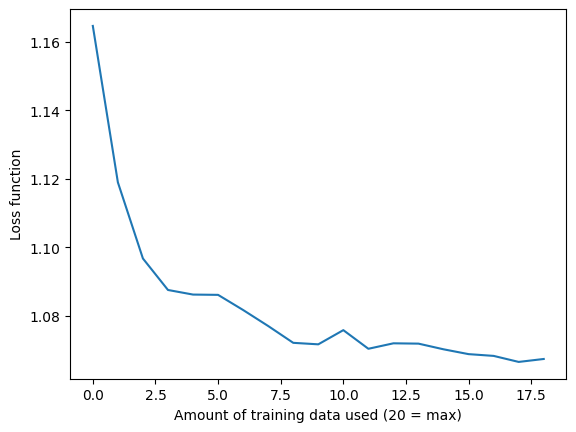

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

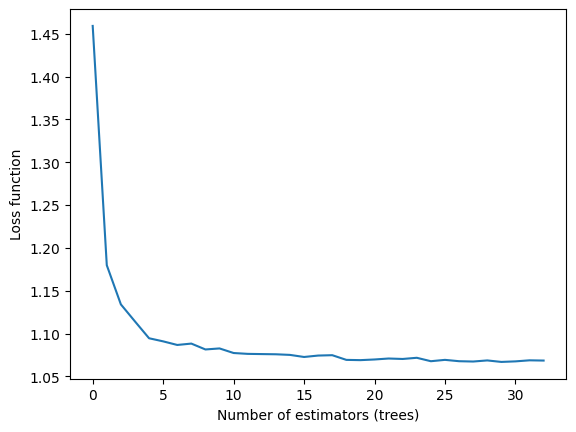

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

I would cut the number of estimators (trees) because it provide less interesting information than amount training data used. The training data plot is more important since it tells use how the model improves as more data is added. It's a clear indicator of how well the model learns and whether or not adding more data is useful. While with trees, there is a point where more of them does not improve the model much.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# Dataset 1: Diabetes Health Indicator

### *Reading in the Dataset:*

In [9]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

files = os.listdir(path)
df_file = files[0]

df_diabetes = pd.read_csv(os.path.join(path, df_file))
df_diabetes.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### *Random Forest model*

In [14]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
X = df_diabetes.drop(columns=["Diabetes_012"])
y = df_diabetes["Diabetes_012"]

random_state = 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

rf = RandomForestRegressor(random_state = random_state)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)

print("RMSE:", rmse)


RMSE: 0.6564704945437501


### *Cross-Validation before tuning*

In [22]:
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
print(-scores.mean())

0.6551274167233656


### *Hyperparameter tuning*

In [15]:
rmse_list = []
for n in range(10, 110, 10):
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse_list.append(root_mean_squared_error(y_test, preds))

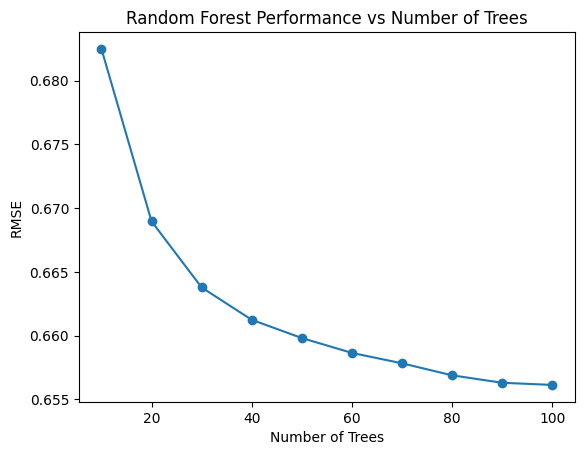

In [21]:
plt.plot(range(10, 110, 10), rmse_list, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("Random Forest Performance vs Number of Trees")
plt.show()

In [19]:
from scipy.stats import randint

random_search = RandomizedSearchCV(
    rf,
    param_distributions={
        "n_estimators": randint(50, 200),
        "max_depth": randint(5, 20),
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 5)
    },
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=0,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_params = random_search.best_estimator_

predictions = best_params.predict(X_test)

rmse_tuned = root_mean_squared_error(y_test, preds)


In [20]:
print("RMSE after tuning:", rmse_tuned)

RMSE after tuning: 0.6561278489895777


### *Cross Validation after tuning:*

In [23]:
scores = cross_val_score(
    random_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -scores
print("CV RMSE (after tuning):", rmse_scores)
print("Mean RMSE (after tuning):", rmse_scores.mean())

CV RMSE (after tuning): [0.62655731 0.62942796 0.62229065 0.62328453 0.62320859]
Mean RMSE (after tuning): 0.6249538082917929


Evaluation: Even after tuning, my RMSE barely fluctuated. The difference is most likely noise from random test splits or CV variations. This goes to show that the baseline model was already good, and tuning doesn't meaningfully improve the model.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

There was no graph for the following page range so I chose a random one in the previous chapter.

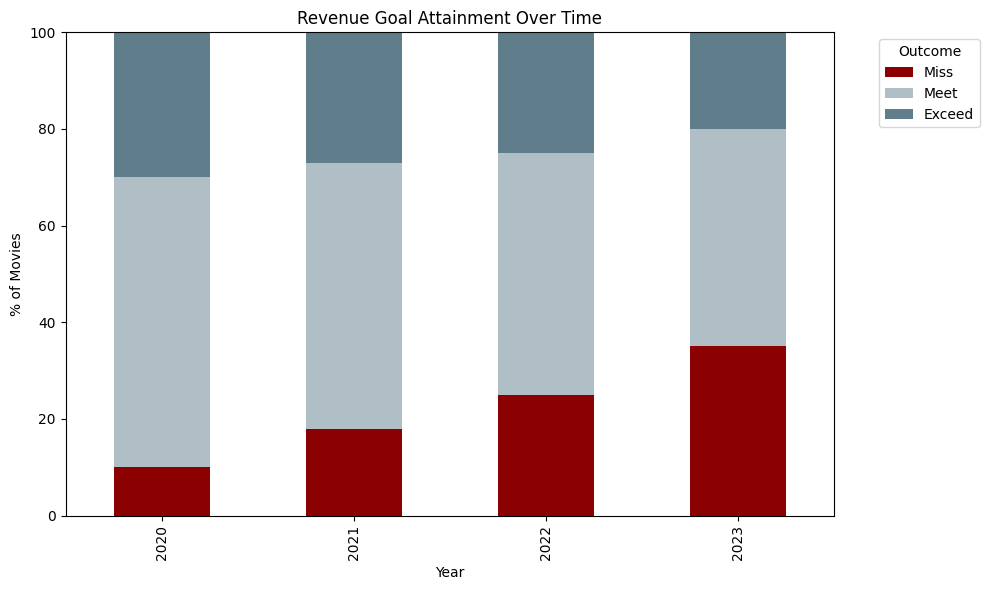

In [24]:
years = ['2020', '2021', '2022', '2023']
data2 = {
    'Year': years,
    'Miss': [10, 18, 25, 35],
    'Meet': [60, 55, 50, 45],
    'Exceed': [30, 27, 25, 20]
}
df2 = pd.DataFrame(data2)

df2.set_index('Year').plot(kind='bar', stacked=True, figsize=(10, 6),
                           color=['#8B0000', '#B0BEC5', '#607D8B'])

plt.title("Revenue Goal Attainment Over Time")
plt.ylabel("% of Movies")
plt.ylim(0, 100)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()